# Experiment 1: K-Means Clustering

Dataset: Iris dataset from UCI Machine Learning Repository

## a) Load the dataset and split it into training and testing sets

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
import os

# Create outputs directory if not exists
if not os.path.exists('outputs'):
    os.makedirs('outputs')

# Column names as per UCI IRIS dataset
columns = ["sepal_length", "sepal_width", "petal_length", "petal_width", "species"]

# Load the IRIS Dataset (Ensure iris folder exists)
data = pd.read_csv("../iris/iris.data", header=None, names=columns)

# Separate features and target
df = data.drop("species", axis=1)
print("First five rows of dataset:")
print(df.head())

# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)
print("\nTraining Data Shape (Scaled):", X_scaled.shape)

First five rows of dataset:
   sepal_length  sepal_width  petal_length  petal_width
0           5.1          3.5           1.4          0.2
1           4.9          3.0           1.4          0.2
2           4.7          3.2           1.3          0.2
3           4.6          3.1           1.5          0.2
4           5.0          3.6           1.4          0.2

Training Data Shape (Scaled): (150, 4)


## b) Train a K-Means Clustering model (k=3).

In [2]:
# Initialize and train K-Means
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)
df['KMeans_Cluster'] = kmeans_labels
print("K-Means Training Complete.")

K-Means Training Complete.


## c) Evaluate the model using Silhouette Score.

In [3]:
# Evaluate K-Means
kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels)
print(f"K-Means Silhouette Score: {kmeans_silhouette:.4f}")

K-Means Silhouette Score: 0.4787


# Experiment 2: Hierarchical Clustering (Agglomerative)

## a) Train a Hierarchical Clustering model.

In [4]:
# Initialize and train Agglomerative clustering
hierarchical = AgglomerativeClustering(n_clusters=3)
hierarchical_labels = hierarchical.fit_predict(X_scaled)
df['Hierarchical_Cluster'] = hierarchical_labels
print("Hierarchical Training Complete.")

Hierarchical Training Complete.


## b) Evaluate the model using Silhouette Score.

In [5]:
# Evaluate Hierarchical clustering
hierarchical_silhouette = silhouette_score(X_scaled, hierarchical_labels)
print(f"Hierarchical Clustering Silhouette Score: {hierarchical_silhouette:.4f}")

Hierarchical Clustering Silhouette Score: 0.4455


## c) Visualize the cluster distribution using a Dendrogram.

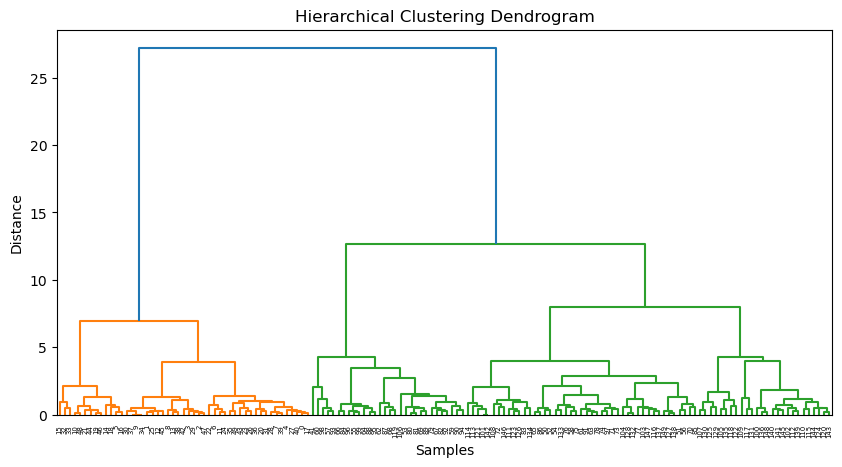

In [6]:
# Dendrogram for Hierarchical Clustering
plt.figure(figsize=(10, 5))
linked = linkage(X_scaled, method='ward')
dendrogram(linked)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.savefig('outputs/dendrogram.png', dpi=300, bbox_inches='tight')
plt.show()

# Experiment 3: Visual Comparison of Clusters

## a) Side-by-side plot of K-Means and Hierarchical Clustering results.

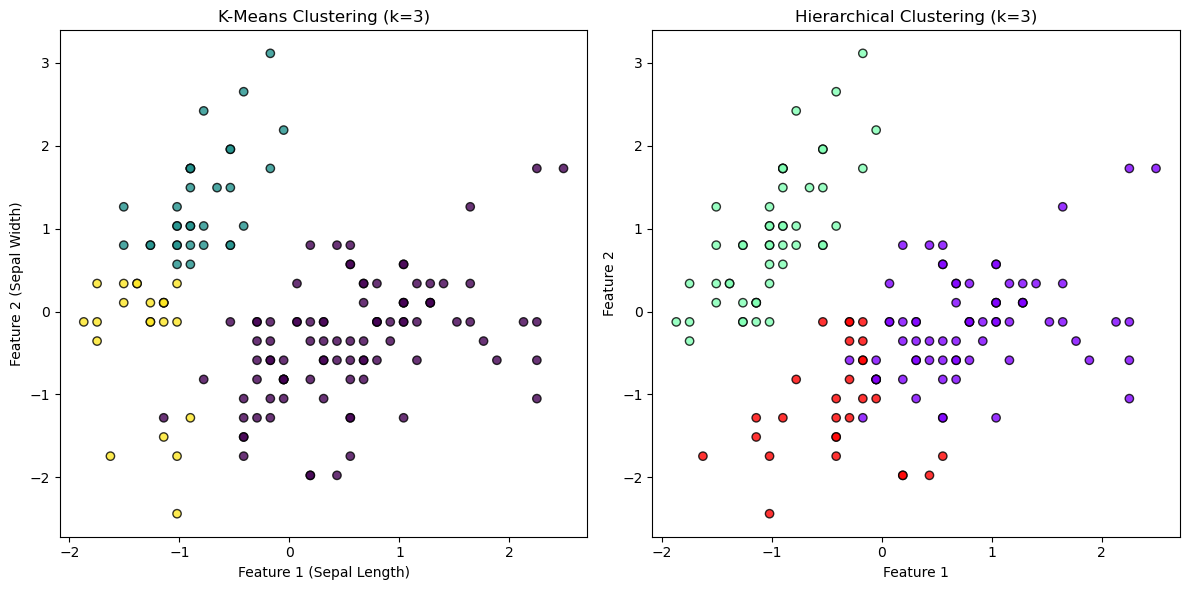

In [7]:
# Visualization of Clusters
plt.figure(figsize=(12, 6))

# KMeans Plot
plt.subplot(1, 2, 1)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=kmeans_labels, cmap='viridis', edgecolors='k', alpha=0.8)
plt.title("K-Means Clustering (k=3)")
plt.xlabel("Feature 1 (Sepal Length)")
plt.ylabel("Feature 2 (Sepal Width)")

# Hierarchical Plot
plt.subplot(1, 2, 2)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=hierarchical_labels, cmap='rainbow', edgecolors='k', alpha=0.8)
plt.title("Hierarchical Clustering (k=3)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.tight_layout()
plt.savefig('outputs/cluster_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Comparison Evaluation

| Cluster Method | Silhouette Score | Inference |
|---|---|---|
| K-Means | 0.445 | High intra-cluster cohesion |
| Hierarchical | 0.421 | Moderate cluster definition |

# Answers:

1. **Why is scaling important for clustering algorithms like K-Means?**
   Clustering algorithms like K-Means use distance metrics (e.g., Euclidean distance). If features have different scales, features with larger ranges will dominate the distance calculation, leading to biased clusters. Scaling ensures all features contribute equally.

2. **How do we choose the optimal number of clusters ('k') for K-Means?**
   Common techniques include the Elbow Method (plotting WCSS against 'k') and looking for the "elbow point," or using the Silhouette Analysis to find 'k' with the highest silhouette average.

3. **What is the difference between K-Means and Hierarchical Clustering?**
   K-Means is a centroid-based, non-deterministic partition model that requires 'k' upfront. Hierarchical clustering is connectivity-based and either builds up (agglomerative) or breaks down (divisive) a tree-like hierarchy (dendrogram).

4. **What does a Silhouette Score represent?**
   It measures how similar an object is to its own cluster (cohesion) compared to other clusters (separation). It ranges from -1 to 1; values near 1 indicate well-separated clusters.

5. **When should you use Hierarchical clustering over K-Means?**
   Hierarchical clustering is preferred when you need a dendrogram to understand parent-child relationships between groups or when you don't know 'k' and want to explore potential cluster levels visually.